In [1]:
%pip install dowhy causaldata scikit-learn pandas numpy matplotlib

/Users/viegas/Projects/ufv/mestrado/causality-for-data-scientists-course/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Descomente isso se tiver no Google Colab!!
# !git clone https://github.com/gfviegas/causality-for-data-scientists-course.git
# %cd causality-for-data-scientists-course/notebooks

# Estimando Efeitos Causais com `DoWhy`

Lá no Paradoxo de Simpson você já viu um confundidor bagunçando uma comparação simples (a idade, lembra?). E na Descoberta Causal você viu como recuperar a estrutura de um grafo causal a partir dos dados.

Só que até agora a gente ficou só na estrutura. Beleza, você tem um grafo. E agora? Como você transforma isso num número real, tipo "esse tratamento aumenta o resultado em X"?

É disso que esse notebook trata: pegar um grafo causal (mesmo que simples) e uns dados, e chegar num número que dê pra confiar. Vamos usar o dataset **National Supported Work (NSW)**, um programa real de treinamento profissional dos anos 1970. A vantagem: como parte dele foi um experimento aleatorizado de verdade, já sabemos a resposta certa de antemão. Então dá pra conferir se cada método "acertou" ou não.

> **Por que usar um experimento aleatorizado como benchmark?** Porque assim dá pra comparar as estimativas de métodos observacionais contra uma resposta que sabemos ser verdadeira, sem depender só da teoria.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import dowhy
from dowhy import CausalModel
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [2]:
def fmt(x, casas=2):
    """Formata um número em estilo brasileiro: vírgula decimal, ponto de milhar."""
    return f'{x:,.{casas}f}'.translate(str.maketrans(',.', '.,'))

## O Experimento (NSW)

O **National Supported Work (NSW)** foi um programa de treinamento profissional de verdade, rodado nos anos 1970 (LaLonde, 1986; Dehejia & Wahba, 1999). Os participantes foram sorteados aleatoriamente pra receber de 9 a 18 meses de experiência de trabalho garantida (`treat = 1`) ou não (`treat = 0`). O resultado que nos interessa é o **salário real em 1978** (`re78`), em dólares.

Como o sorteio foi aleatório, não existe confundimento aqui: uma simples diferença de médias já nos dá o efeito causal. É por isso que essa amostra experimental vira nosso "gabarito" pra tudo que vem depois.

In [3]:
from causaldata import nsw_mixtape

nsw = nsw_mixtape.load_pandas().data
print('Amostra experimental do NSW:', nsw.shape)
nsw[['treat', 'age', 'educ', 'black', 're74', 're75', 're78']].head()

Amostra experimental do NSW: (445, 11)


,treat,age,educ,black,re74,re75,re78
0,1,37,11,1,0.0,0.0,9930.045898
1,1,22,9,0,0.0,0.0,3595.894043
2,1,30,12,1,0.0,0.0,24909.449219
3,1,27,11,1,0.0,0.0,7506.145996
4,1,33,8,1,0.0,0.0,289.789886


In [4]:
nsw['treat'].value_counts()

treat
0    260
1    185
Name: count, dtype: int64

In [5]:
mean_by_treat = nsw.groupby('treat')['re78'].mean()
true_ate = mean_by_treat[1] - mean_by_treat[0]

print(f'Salário médio em 1978, controle : ${fmt(mean_by_treat[0])}')
print(f'Salário médio em 1978, tratado  : ${fmt(mean_by_treat[1])}')
print()
print(f'ATE experimental VERDADEIRO = ${fmt(true_ate)}')

Salário médio em 1978, controle : $4.554,80
Salário médio em 1978, tratado  : $6.349,14

ATE experimental VERDADEIRO = $1.794,34


Esse número já vale sem nenhum tipo de ajuste, exatamente porque o tratamento foi sorteado aleatoriamente. É o alvo que todo estimador lá na frente vai tentar acertar.

## Versão Observacional

Experimentos aleatorizados são caros e raros. Na prática, é comum um analista ser tentado a comparar um grupo tratado com um grupo de comparação "de conveniência", tirado de uma pesquisa qualquer, em vez de um controle sorteado.

Foi exatamente essa a crítica famosa de LaLonde (1986): ele pegou os participantes tratados do NSW e comparou com um grupo de comparação não experimental tirado da **Current Population Survey (CPS)** (gente comum respondendo uma pesquisa, não participantes do programa), e mostrou que os métodos econométricos padrão da época erravam feio a estimativa do efeito real.

Vamos reproduzir esse exercício aqui. Ficamos só com os tratados do NSW e descartamos o controle aleatorizado original, trocando por essa amostra da CPS.

Idade, educação, raça, estado civil e os **salários pré-tratamento** (`re74`, `re75`) foram todos medidos.

In [6]:
from causaldata import cps_mixtape

cps = cps_mixtape.load_pandas().data
print('Amostra de comparação da CPS:', cps.shape)

Amostra de comparação da CPS: (15992, 11)


In [7]:
treated = nsw[nsw['treat'] == 1].copy()
combined = pd.concat([treated, cps], ignore_index=True)
covariates = ['age', 'educ', 'black', 'hisp', 'marr', 'nodegree', 're74', 're75']

print(f'Dataset observacional: {len(treated)} tratados do NSW + {len(cps)} controles da CPS = {len(combined)} linhas')

Dataset observacional: 185 tratados do NSW + 15992 controles da CPS = 16177 linhas


### Mini-quiz

Antes de rodar a próxima célula, pense um pouco:

Você acha que a diferença bruta de médias vai chegar perto do \$1.794 verdadeiro?

<!-- Repare que os controles da CPS não passaram por nenhum sorteio, então talvez eles sejam sistematicamente diferentes dos participantes do NSW de alguma forma. -->

In [8]:
naive_by_treat = combined.groupby('treat')['re78'].mean()
naive_ate = naive_by_treat[1] - naive_by_treat[0]

print(f'Salário médio em 1978, controles da CPS : ${fmt(naive_by_treat[0])}')
print(f'Salário médio em 1978, tratados do NSW   : ${fmt(naive_by_treat[1])}')
print()
print(f'Estimativa observacional INGÊNUA = ${fmt(naive_ate)}')
print(f'ATE experimental VERDADEIRO      = ${fmt(true_ate)}')

Salário médio em 1978, controles da CPS : $14.846,66
Salário médio em 1978, tratados do NSW   : $6.349,14

Estimativa observacional INGÊNUA = $-8.497,52
ATE experimental VERDADEIRO      = $1.794,34


A comparação ingênua diz que o programa deixou as pessoas milhares de dólares mais pobres. O oposto da conclusão do experimento aleatorizado.

Isso acontece porque os respondentes da CPS são, em média, uma população empregada e com salário mais alto. Comparar eles direto com um grupo de participantes desfavorecidos do NSW confunde "quem recebeu o tratamento" com "quem já ganha mais de qualquer jeito". Praticamente o mesmo tipo de bagunça que a idade causou lá no Paradoxo de Simpson.

## Identificação com o DoWhy

Antes de calcular qualquer coisa, declaramos nossas suposições causais como um grafo: `treat` e `re78` compartilham as covariáveis observadas como causas comuns e, supomos, não sobra nenhum confundidor não observado depois de ajustar por elas. O DoWhy transforma isso num **estimando backdoor** formal.

In [9]:
model = CausalModel(
    data=combined,
    treatment='treat',
    outcome='re78',
    common_causes=covariates,
)

identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
   d                                                         
────────(E[re78|educ,re74,age,nodegree,hisp,re75,black,marr])
d[treat]                                                     
Estimand assumption 1, Unconfoundedness: If U→{treat} and U→re78 then P(re78|treat,educ,re74,age,nodegree,hisp,re75,black,marr,U) = P(re78|treat,educ,re74,age,nodegree,hisp,re75,black,marr)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
   d                                                         
────────(E[re78|educ,re74,age,nodegree,hisp,re75,black,marr])
d[treat]                                                     
Estimand assumption 1, Unconfoundedness: If U→{treat} and U→re78 then P(re78|treat,educ,re74,age,nodegree,hisp,re75,black,m

Em outras palavras: o DoWhy encontrou um **conjunto de ajuste backdoor** válido (`age, educ, black, hisp, marr, nodegree, re74, re75`) e nos diz que, se ajustarmos exatamente por essas variáveis, a associação que sobrar entre `treat` e `re78` pode ser interpretada como causal (supondo que não falta nenhum confundidor).

Essa é a promessa do grafo colocada em prática num dataset real.

## 3 maneiras de estimar

Com a identificação resolvida, vamos calcular a mesma fórmula backdoor de três formas diferentes. Sem fórmula, só a ideia de cada uma:

- **Ajuste por regressão**: aprende um modelo do resultado e simula "e se essa pessoa tivesse (ou não) passado pelo tratamento?" pra cada uma;
- **Pareamento por Score de propensão (PSM)**: pra cada tratado, acha controles parecidos e compara;
- **IPW**: dá mais peso pra quem é raro no seu grupo, pra reequilibrar a comparação.

In [10]:
est_regression = model.estimate_effect(identified_estimand, method_name='backdoor.linear_regression')
est_psm = model.estimate_effect(identified_estimand, method_name='backdoor.propensity_score_matching')
est_ipw = model.estimate_effect(identified_estimand, method_name='backdoor.propensity_score_weighting')

In [19]:
results = pd.DataFrame({
    'Method': ['ATE experimental verdadeiro', 'Diferença ingênua de médias',
               'Ajuste por regressão', 'Pareamento por score de propensão', 'IPW'],
    'Estimate ($)': [true_ate, naive_ate, est_regression.value, est_psm.value, est_ipw.value],
})
results

,Method,Estimate ($)
0,ATE experimental verdadeiro,1794.342285
1,Diferença ingênua de médias,-8497.515625
2,Ajuste por regressão,699.131678
3,Pareamento por score de propensão,-8944.935167
4,IPW,-7268.775879


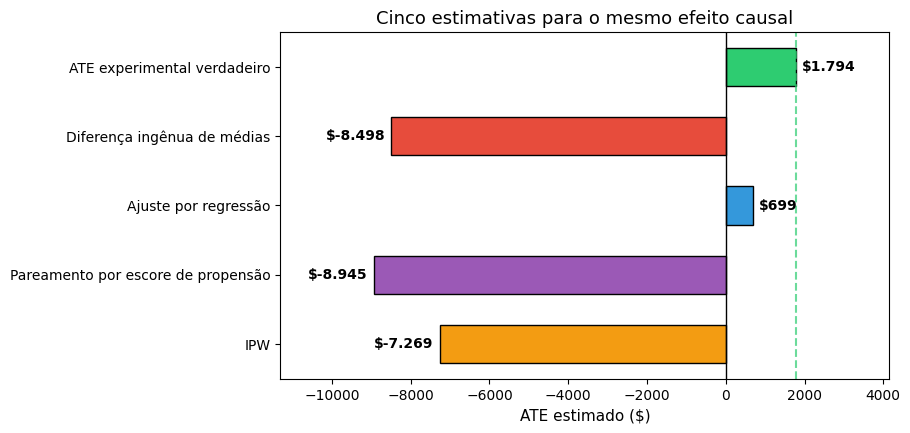

In [12]:
fig, ax = plt.subplots(figsize=(10.5, 4.5))
colors = ['#2ECC71', '#E74C3C', '#3498DB', '#9B59B6', '#F39C12']
bars = ax.barh(results['Method'][::-1], results['Estimate ($)'][::-1],
               color=colors[::-1], edgecolor='black', height=0.55)
ax.margins(x=0.22)
ax.axvline(0, color='black', linewidth=1)
ax.axvline(true_ate, color='#2ECC71', linestyle='--', linewidth=1.5, alpha=0.7)
for bar, v in zip(bars, results['Estimate ($)'][::-1]):
    ax.text(v + (150 if v >= 0 else -150), bar.get_y() + bar.get_height() / 2,
            f'${fmt(v, 0)}', va='center', ha='left' if v >= 0 else 'right',
            fontsize=10, fontweight='bold')
ax.set_xlabel('ATE estimado ($)', fontsize=11)
ax.set_title('Cinco estimativas para o mesmo efeito causal', fontsize=13)
fig.subplots_adjust(left=0.32)
plt.savefig('../figures/3_ate_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

O ajuste por regressão chega bem mais perto do \$1.794 real do que a comparação ingênua, só que não é perfeito. 

E repara: **o pareamento e o IPW quase não melhoram nada em relação à estimativa ingênua**. Ajustar pelas covariáveis "certas" não foi suficiente. 

Tem mais alguma coisa errada... né?

### Por que o pareamento e o IPW falharam?

O ajuste backdoor assume, silenciosamente, que existe **sobreposição** (também chamada de *positividade*): pra cada perfil de covariáveis nos dados, precisa existir uma chance real de observar unidades tratadas e de controle.

Se tratados e controles ocupam regiões quase totalmente diferentes do espaço de covariáveis, o pareamento não tem com o que parear, e os pesos do IPW explodem.

Vamos conferir a distribuição do score de propensão diretamente.

In [13]:
X = combined[covariates].values
T = combined['treat'].values
ps_model = LogisticRegression(max_iter=1000).fit(X, T)
combined['propensity_score'] = ps_model.predict_proba(X)[:, 1]

overlap_summary = combined.groupby('treat')['propensity_score'].describe()[['mean', '50%', 'min', 'max']]
overlap_summary.columns = ['média', 'mediana', 'mín', 'máx']
overlap_summary

,média,mediana,mín,máx
treat,,,,
0,0.011016,0.000628,0.000005,0.360133
1,0.054688,0.050834,0.000058,0.182252


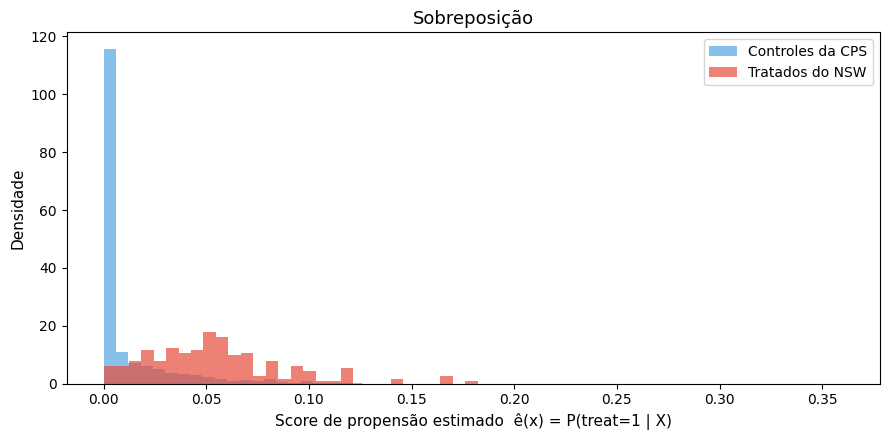

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(combined.loc[combined.treat == 0, 'propensity_score'], bins=60, alpha=0.6,
        label='Controles da CPS', color='#3498DB', density=True)
ax.hist(combined.loc[combined.treat == 1, 'propensity_score'], bins=30, alpha=0.7,
        label='Tratados do NSW', color='#E74C3C', density=True)
ax.set_xlabel('Score de propensão estimado  ê(x) = P(treat=1 | X)', fontsize=11)
ax.set_ylabel('Densidade', fontsize=11)
ax.set_title('Sobreposição', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../figures/3_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
print('Score de propensão mediano, controles:', fmt(overlap_summary.loc[0, 'mediana'], 4))
print('Score de propensão mediano, tratados :', fmt(overlap_summary.loc[1, 'mediana'], 4))

Score de propensão mediano, controles: 0,0006
Score de propensão mediano, tratados : 0,0508


Esse é o achado que LaLonde (1986) ficou famoso por mostrar: a CPS é uma população empregada, geralmente com salário mais alto, e quase ninguém nela se parece com um treinando plausível do NSW depois que você leva as covariáveis em conta. 

A maioria dos controles tem uma probabilidade de tratamento quase zero, exatamente o perfil que faz os pesos do IPW explodirem e faz o PSM parear tratados com controles "mais próximos" de qualidade ruim.

O ajuste por regressão não falha de um jeito tão visível, mas está **extrapolando** silenciosamente pra regiões sem dado de controle de verdade. É por isso que ele também erra o alvo.

Um remédio prático: restringir a análise à região de suporte comum (por exemplo, cortar unidades cujo score de propensão fica fora do intervalo observado entre os tratados).

Vamos tentar a versão mais simples disso.

In [20]:
lo, hi = combined.loc[combined.treat == 1, 'propensity_score'].agg(['min', 'max'])
trimmed = combined[(combined.propensity_score >= lo) & (combined.propensity_score <= hi)].copy()

print(f'Amostra cortada: {trimmed.shape[0]} linhas '
      f'({(combined.treat==1).sum()} tratados, {(trimmed.treat==0).sum()} controles mantidos '
      f'de {(combined.treat==0).sum()} controles originais)')

Amostra cortada: 11856 linhas (185 tratados, 11671 controles mantidos de 15992 controles originais)


In [21]:
trim_model = CausalModel(data=trimmed, treatment='treat', outcome='re78', common_causes=covariates)
trim_identified = trim_model.identify_effect(proceed_when_unidentifiable=True)
trim_reg = trim_model.estimate_effect(trim_identified, method_name='backdoor.linear_regression')
trim_psm = trim_model.estimate_effect(trim_identified, method_name='backdoor.propensity_score_matching')

print(f'Regressão cortada : ${fmt(trim_reg.value)}  (era ${fmt(est_regression.value)} sem cortar)')
print(f'PSM cortado       : ${fmt(trim_psm.value)}  (era ${fmt(est_psm.value)} sem cortar)')
print(f'ATE verdadeiro     : ${fmt(true_ate)}')

Regressão cortada : $905,40  (era $699,13 sem cortar)
PSM cortado       : $-2.365,14  (era $-8.944,94 sem cortar)
ATE verdadeiro     : $1.794,34


Cortar pro suporte comum move as duas estimativas na direção certa, mas não fecha a conta totalmente. 

A CPS continua sendo uma população fundamentalmente diferente mesmo depois do corte.

Dehejia & Wahba (1999) resolvem isso de um jeito mais completo, construindo subamostras de comparação sob medida.

O diagnóstico (sobreposição ruim), não necessariamente a correção completa, é o ponto desse exercício.

## Refutação

Uma estimativa causal só é tão boa quanto as suposições por trás dela, e essas suposições não dá pra verificar só com os dados.

Testes de refutação tentam quebrar a estimativa de propósito. Vamos rodar os três refutadores padrão do DoWhy na estimativa de regressão (sem corte):

- **Causa comum aleatória**: adiciona uma variável aleatória ao conjunto de ajuste. Um efeito de verdade quase não deve se mexer;
- **Tratamento placebo**: troca `treat` por uma versão embaralhada aleatoriamente. Um efeito de verdade deve desabar pra perto de zero;
- **Subconjunto de dados**: reestima numa subamostra aleatória de 80%. Um efeito de verdade deve ficar estável.

In [22]:
refute_random = model.refute_estimate(identified_estimand, est_regression, method_name='random_common_cause')
refute_placebo = model.refute_estimate(identified_estimand, est_regression, method_name='placebo_treatment_refuter', placebo_type='permute')
refute_subset = model.refute_estimate(identified_estimand, est_regression, method_name='data_subset_refuter', subset_fraction=0.8)

print(refute_random)
print()
print(refute_placebo)
print()
print(refute_subset)

Refute: Add a random common cause
Estimated effect:699.131677505482
New effect:698.9771600791105
p value:0.92


Refute: Use a Placebo Treatment
Estimated effect:699.131677505482
New effect:-23.286024244304734
p value:0.96


Refute: Use a subset of data
Estimated effect:699.131677505482
New effect:694.5287996292641
p value:0.9199999999999999



As três refutações se comportam exatamente como uma estimativa confiável deveria:
1. A causa comum aleatória quase não muda a estimativa (bem menos de 1%).
2. O tratamento placebo derruba o efeito pra perto de zero (uma fração pequena do \$699 original, e ainda com o sinal trocado)
3. A subamostragem deixa a estimativa estável (ainda uns \$695 com 80% dos dados).

Nada disso *prova* que a estimativa está certa (refutação não consegue descartar um confundidor não medido), mas descarta vários jeitos comuns de dar errado: um padrão espúrio que uma permutação aleatória também produziria, uma estimativa puxada por poucos pontos influentes, sensibilidade a covariáveis extras, etc.

## E se eu esquecer um confundidor?

Até agora, ajustamos por `re74` e `re75` (os salários dos dois anos antes do tratamento). Na literatura, esses são conhecidos como os confundidores mais importantes desse dataset.

Salário passado prevê tanto salário futuro quanto, em comparações observacionais, se a pessoa aparece numa amostra de participantes do programa ou numa pesquisa qualquer.

Vamos tirar eles do conjunto de ajuste e ver o que acontece com a estimativa de regressão.

In [24]:
covariates_misspecified = ['age', 'educ', 'black', 'hisp', 'marr', 'nodegree']  # re74 e re75 removidos

model_misspec = CausalModel(data=combined, treatment='treat', outcome='re78', common_causes=covariates_misspecified)
identified_misspec = model_misspec.identify_effect(proceed_when_unidentifiable=True)
est_misspec = model_misspec.estimate_effect(identified_misspec, method_name='backdoor.linear_regression')

In [25]:
comparison = pd.DataFrame({
    'Adjustment set': ['Completo (idade, educação, raça, estado civil, sem diploma, re74, re75)',
                        'Sem re74 e re75'],
    'Estimated ATE ($)': [est_regression.value, est_misspec.value],
})
print(comparison)
print()
print(f'ATE experimental verdadeiro: ${fmt(true_ate)}')

                                      Adjustment set  Estimated ATE ($)
0  Completo (idade, educação, raça, estado civil,...         699.131678
1                                    Sem re74 e re75       -2973.487067

ATE experimental verdadeiro: $1.794,34


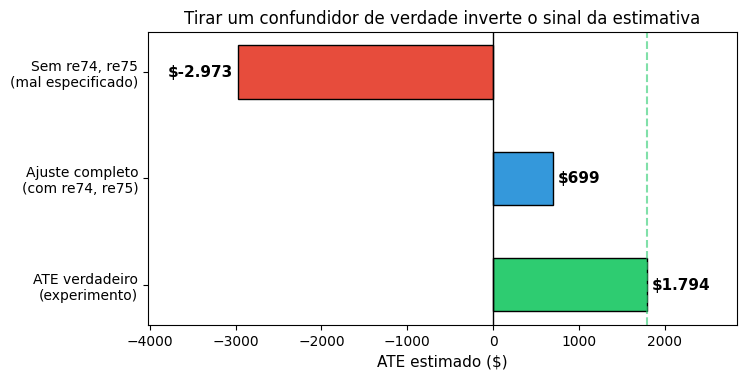

In [26]:
fig, ax = plt.subplots(figsize=(9.5, 3.8))
labels = ['ATE verdadeiro\n(experimento)', 'Ajuste completo\n(com re74, re75)', 'Sem re74, re75\n(mal especificado)']
values = [true_ate, est_regression.value, est_misspec.value]
colors = ['#2ECC71', '#3498DB', '#E74C3C']
bars = ax.barh(labels, values, color=colors, edgecolor='black', height=0.5)
ax.margins(x=0.22)
ax.axvline(0, color='black', linewidth=1)
ax.axvline(true_ate, color='#2ECC71', linestyle='--', linewidth=1.5, alpha=0.6)
for bar, v in zip(bars, values):
    ax.text(v + (60 if v >= 0 else -60), bar.get_y() + bar.get_height() / 2,
            f'${fmt(v, 0)}', va='center', ha='left' if v >= 0 else 'right',
            fontsize=11, fontweight='bold')
ax.set_xlabel('ATE estimado ($)', fontsize=11)
ax.set_title('Tirar um confundidor de verdade inverte o sinal da estimativa', fontsize=12)
fig.subplots_adjust(left=0.28)
plt.savefig('../figures/3_misspecification.png', dpi=150, bbox_inches='tight')
plt.show()

Tirar duas variáveis, com todas as outras covariáveis ainda ajustadas, faz a estimativa voltar de um número positivo modesto pra perto de um número negativo grande. Quase de volta pra estimativa totalmente ingênua.

Esse é o significado prático do critério backdoor: não basta ajustar por *algumas* covariáveis plausíveis, é preciso um conjunto **válido** que bloqueie todo caminho backdoor. 

Se você esquece um confundidor de verdade, o viés que ele carregava volta na mesma hora.

## Concluindo...

### 1. Identificar, estimar e refutar é um pipeline, não um passo só

Identificação diz *o quê* calcular, a estimação calcula e a  refutação testa se você deveria não confiar no resultado. 

### 2. As covariáveis "certas" não bastam, sobreposição também importa

Regressão, pareamento e IPW miram na mesma fórmula backdoor, mas podem discordar bastante em amostras finitas quando tratados e controles não ocupam a mesma região do espaço de covariáveis.

Diagnosticar a sobreposição (um histograma simples de Score de propensão) já explicou boa parte de por que o PSM e o IPW ficaram atrás da regressão aqui.

### 3. Esquecer um confundidor de verdade é o erro mais perigoso

Tirar `re74` e `re75`, mesmo ajustando por tudo mais, já foi suficiente pra mandar a estimativa de volta perto do número ingênuo e enviesado. Isso não é abstrato: custou uns \$3.700 de valor estimado do programa nesse exemplo único.

### 4. Testes de refutação pegam algumas falhas, não todas

Passar nos três refutadores é reconfortante, mas não é prova de que está tudo certo. Nenhum deles detecta um confundidor *não medido*. Eles descartam falhas específicas e verificáveis, não substituem a suposição de que todos os confundidores foram medidos e ajustados.